In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (7, 4)
sns.set(style="whitegrid", palette="Set2")



In [2]:

df = pd.read_excel("../data/Online Retail.xlsx")


df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

print("Shape:", df.shape)
df.head()


Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:

df.info()
df.describe(include="all").T.head(15)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dfc = df.copy()

# 1) Drop missing CustomerID (cannot segment without ID)
before = len(dfc)
dfc = dfc.dropna(subset=["CustomerID"])
print("Dropped missing CustomerID:", before - len(dfc))

# 2) Remove cancellations (InvoiceNo starts with 'C')
before = len(dfc)
dfc = dfc[~dfc["InvoiceNo"].astype(str).str.startswith("C")]
print("Removed cancellations:", before - len(dfc))

# 3) Keep positive quantities/prices
before = len(dfc)
dfc = dfc[(dfc["Quantity"] > 0) & (dfc["UnitPrice"] > 0)]
print("Removed non-positive qty/price:", before - len(dfc))

# 4) Drop exact duplicates
before = len(dfc)
dfc = dfc.drop_duplicates()
print("Removed duplicate rows:", before - len(dfc))

# LineTotal and making sure InvoiceDate is datetime
dfc["LineTotal"] = dfc["Quantity"] * dfc["UnitPrice"]
dfc["InvoiceDate"] = pd.to_datetime(dfc["InvoiceDate"], errors="coerce")

print("Cleaned shape:", dfc.shape)
dfc.head()


Dropped missing CustomerID: 135080
Removed cancellations: 8905
Removed non-positive qty/price: 40
Removed duplicate rows: 5192
Cleaned shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,LineTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
na_counts = dfc.isna().sum().sort_values(ascending=False)
na_counts


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
LineTotal      0
dtype: int64

In [6]:
# fill na with median if they exist 
num_cols_all = dfc.select_dtypes(include=[np.number]).columns
dfc[num_cols_all] = dfc[num_cols_all].fillna(dfc[num_cols_all].median())


In [7]:

desc = dfc[["Quantity", "UnitPrice", "LineTotal"]].describe().T
desc["mode"] = [dfc[c].mode().iloc[0] if not dfc[c].mode().empty else np.nan 
                for c in ["Quantity", "UnitPrice", "LineTotal"]]
desc


,count,mean,std,min,25%,50%,75%,max,mode
Quantity,392692.0,13.119702,180.492832,1.000,2.00,6.00,12.00,80995.00,1.00
UnitPrice,392692.0,3.125914,22.241836,0.001,1.25,1.95,3.75,8142.75,1.25
LineTotal,392692.0,22.631500,311.099224,0.001,4.95,12.45,19.80,168469.60,15.00


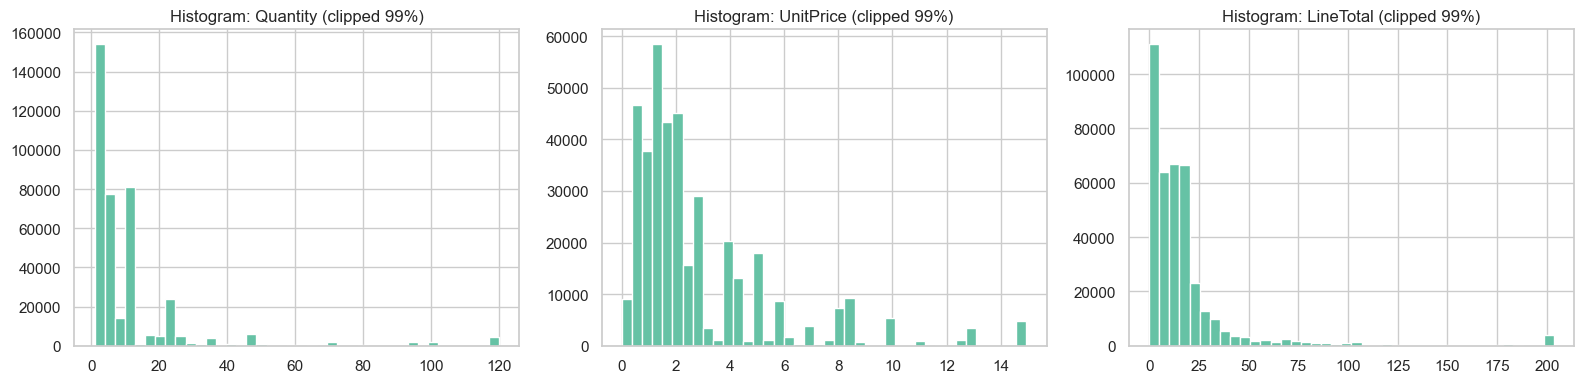

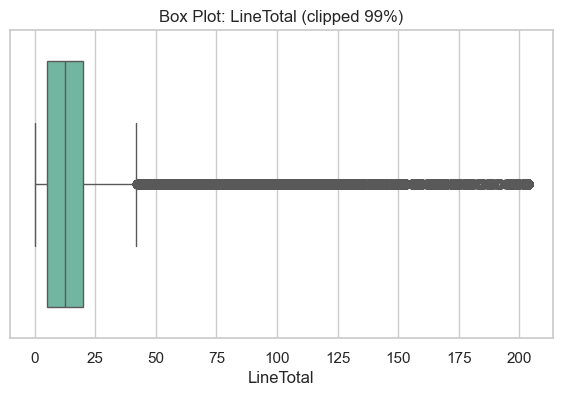

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
dfc["Quantity"].clip(upper=dfc["Quantity"].quantile(0.99)).hist(ax=axes[0], bins=40)
axes[0].set_title("Histogram: Quantity (clipped 99%)")

dfc["UnitPrice"].clip(upper=dfc["UnitPrice"].quantile(0.99)).hist(ax=axes[1], bins=40)
axes[1].set_title("Histogram: UnitPrice (clipped 99%)")

dfc["LineTotal"].clip(upper=dfc["LineTotal"].quantile(0.99)).hist(ax=axes[2], bins=40)
axes[2].set_title("Histogram: LineTotal (clipped 99%)")
plt.tight_layout()
plt.show()

plt.figure()
sns.boxplot(x=dfc["LineTotal"].clip(upper=dfc["LineTotal"].quantile(0.99)))
plt.title("Box Plot: LineTotal (clipped 99%)")
plt.show()


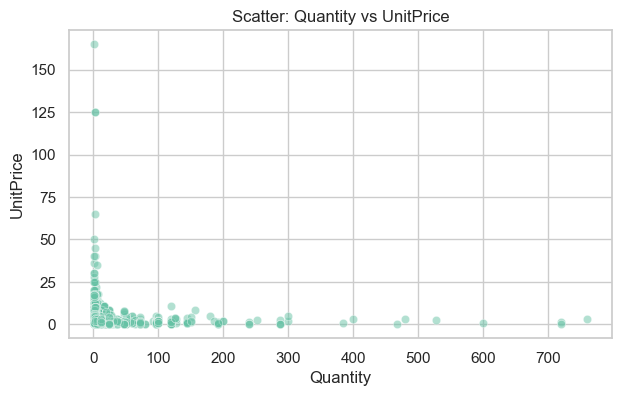

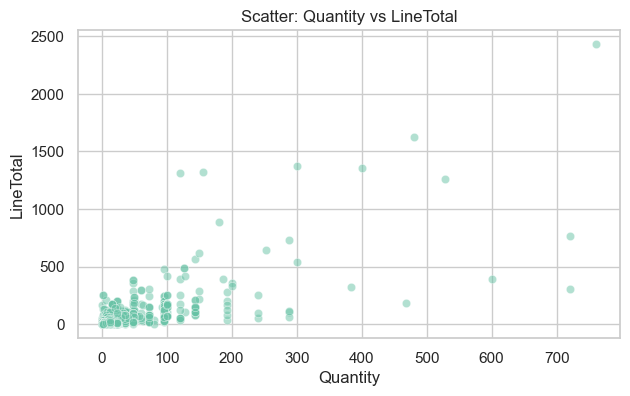

In [9]:
sample_scatter = dfc.sample(min(5000, len(dfc)), random_state=42)

sns.scatterplot(data=sample_scatter, x="Quantity", y="UnitPrice", alpha=0.5)
plt.title("Scatter: Quantity vs UnitPrice")
plt.show()

sns.scatterplot(data=sample_scatter, x="Quantity", y="LineTotal", alpha=0.5)
plt.title("Scatter: Quantity vs LineTotal")
plt.show()


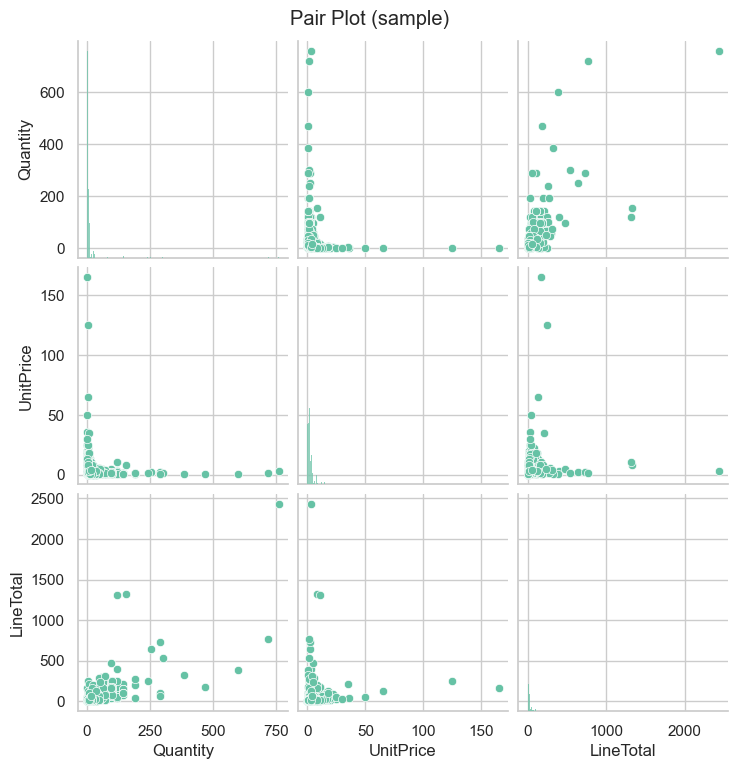

In [10]:
sub = dfc[["Quantity","UnitPrice","LineTotal"]].sample(min(3000, len(dfc)), random_state=42)
sns.pairplot(sub)
plt.suptitle("Pair Plot (sample)", y=1.02)
plt.show()


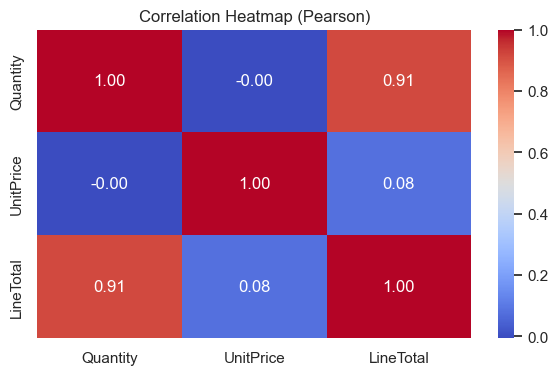

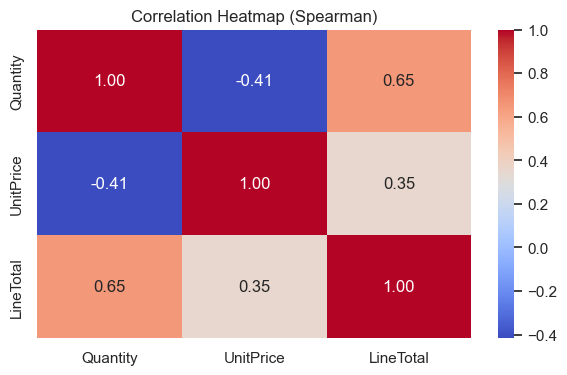

In [11]:
num_for_corr = dfc[["Quantity","UnitPrice","LineTotal"]].copy()

corr_pearson = num_for_corr.corr(method="pearson")
corr_spearman = num_for_corr.corr(method="spearman")

plt.figure()
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Pearson)")
plt.show()

plt.figure()
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Spearman)")
plt.show()


In [12]:
# Z-score on a clipped LineTotal for stability 
lt = dfc["LineTotal"].clip(upper=dfc["LineTotal"].quantile(0.995))
z = zscore(lt.fillna(lt.median()))
dfc["LT_is_outlier_z"] = np.abs(z) >= 3

# IQR method
Q1 = lt.quantile(0.25)
Q3 = lt.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
dfc["LT_is_outlier_iqr"] = (lt < lower) | (lt > upper)

dfc[["LineTotal","LT_is_outlier_z","LT_is_outlier_iqr"]].head()


,LineTotal,LT_is_outlier_z,LT_is_outlier_iqr
0,15.30,False,False
1,20.34,False,False
2,22.00,False,False
3,20.34,False,False
4,20.34,False,False


In [13]:
g = dfc.groupby("CustomerID")

cust = pd.DataFrame({
    "total_spend": g.apply(lambda x: (x["Quantity"]*x["UnitPrice"]).sum()),
    "total_quantity": g["Quantity"].sum(),
    "num_invoices": g["InvoiceNo"].nunique(),
    "unique_products": g["StockCode"].nunique(),
    "avg_unit_price": g["UnitPrice"].mean()
})
cust["avg_basket_value"] = cust["total_spend"] / cust["num_invoices"]

ref_date = dfc["InvoiceDate"].max()
last_purchase = g["InvoiceDate"].max()
first_purchase = g["InvoiceDate"].min()
cust["recency_days"] = (ref_date - last_purchase).dt.days
cust["tenure_days"]   = (last_purchase - first_purchase).dt.days

cust = cust.reset_index()
cust.head()


,CustomerID,total_spend,total_quantity,num_invoices,unique_products,avg_unit_price,avg_basket_value,recency_days,tenure_days
0,12346.0,77183.60,74215,1,1,1.040000,77183.600000,325,0
1,12347.0,4310.00,2458,7,103,2.644011,615.714286,1,365
2,12348.0,1797.24,2341,4,22,5.764839,449.310000,74,282
3,12349.0,1757.55,631,1,73,8.289041,1757.550000,18,0
4,12350.0,334.40,197,1,17,3.841176,334.400000,309,0


In [14]:
cust_desc = cust.drop(columns=["CustomerID"]).describe().T
cust_desc


,count,mean,std,min,25%,50%,75%,max
total_spend,4338.0,2048.688081,8985.230220,3.7500,306.482500,668.570000,1660.597500,280206.02
total_quantity,4338.0,1187.644537,5043.619654,1.0000,159.000000,378.000000,989.750000,196915.00
num_invoices,4338.0,4.272015,7.697998,1.0000,1.000000,2.000000,5.000000,209.00
unique_products,4338.0,61.501153,85.366768,1.0000,16.000000,35.000000,77.000000,1787.00
avg_unit_price,4338.0,4.470820,34.215024,0.1225,2.206415,2.917836,3.832541,2033.10
avg_basket_value,4338.0,417.645735,1796.511343,3.4500,177.867083,291.940000,428.280625,84236.25
recency_days,4338.0,91.536422,100.014169,0.0000,17.000000,50.000000,141.000000,373.00
tenure_days,4338.0,130.448594,132.039554,0.0000,0.000000,92.500000,251.750000,373.00


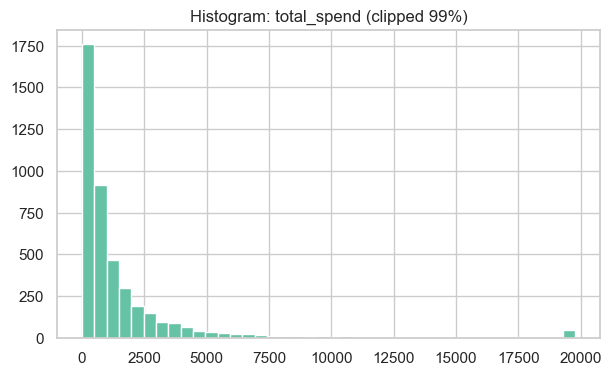

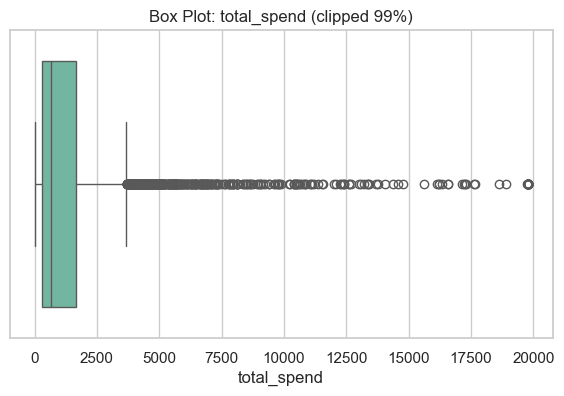

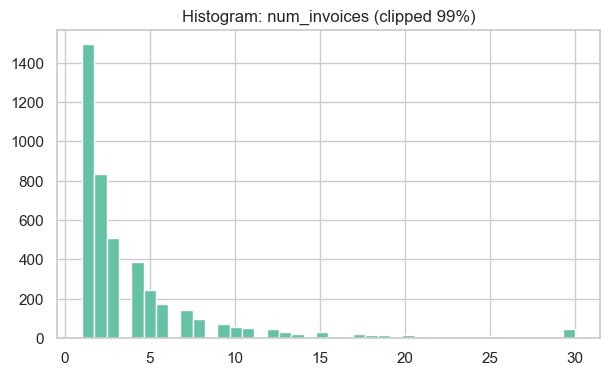

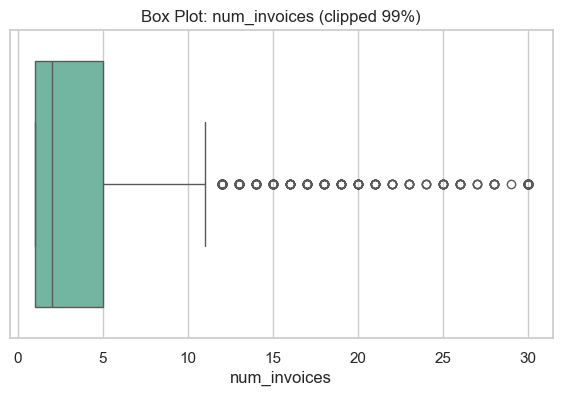

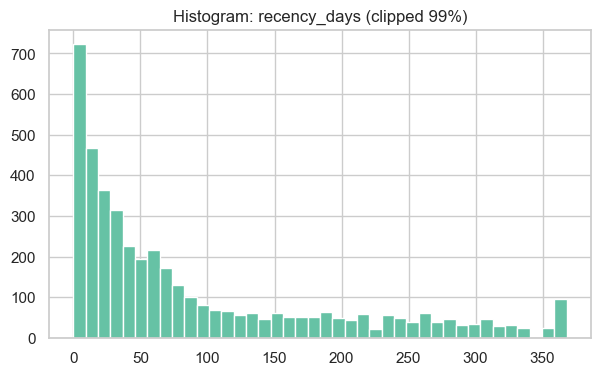

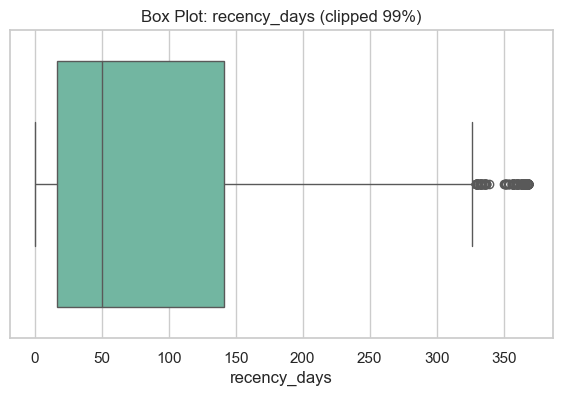

In [15]:
for col in ["total_spend", "num_invoices", "recency_days"]:
    plt.figure()
    cust[col].clip(upper=cust[col].quantile(0.99)).hist(bins=40)
    plt.title(f"Histogram: {col} (clipped 99%)")
    plt.show()

    plt.figure()
    sns.boxplot(x=cust[col].clip(upper=cust[col].quantile(0.99)))
    plt.title(f"Box Plot: {col} (clipped 99%)")
    plt.show()


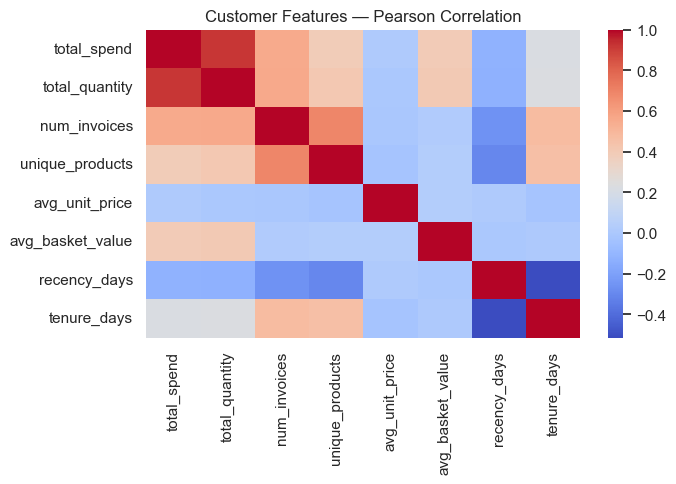

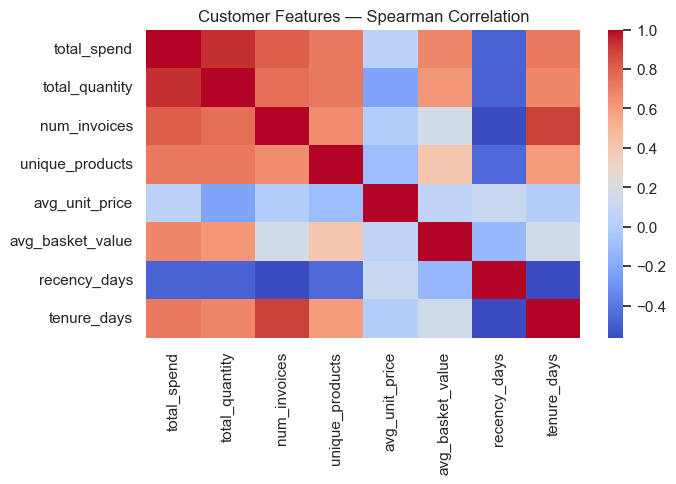

In [16]:
cust_nums = cust.drop(columns=["CustomerID"]).copy()

corrp = cust_nums.corr(method="pearson")
corrs = cust_nums.corr(method="spearman")

plt.figure()
sns.heatmap(corrp, cmap="coolwarm", annot=False)
plt.title("Customer Features — Pearson Correlation")
plt.show()

plt.figure()
sns.heatmap(corrs, cmap="coolwarm", annot=False)
plt.title("Customer Features — Spearman Correlation")
plt.show()


In [17]:
#rfm features
rfm = pd.DataFrame()
rfm["CustomerID"] = cust["CustomerID"]
rfm["Recency"]   = cust["recency_days"]        
rfm["Frequency"] = cust["num_invoices"]
rfm["Monetary"]  = cust["total_spend"]

#other features
feat_cols = [
    "total_spend","total_quantity","num_invoices","unique_products",
    "avg_unit_price","avg_basket_value","recency_days","tenure_days"
]
X_feat_raw = cust[feat_cols].copy()

rfm.head(), X_feat_raw.head()


(   CustomerID  Recency  Frequency  Monetary
 0     12346.0      325          1  77183.60
 1     12347.0        1          7   4310.00
 2     12348.0       74          4   1797.24
 3     12349.0       18          1   1757.55
 4     12350.0      309          1    334.40,
    total_spend  total_quantity  num_invoices  unique_products  avg_unit_price  \
 0     77183.60           74215             1                1        1.040000   
 1      4310.00            2458             7              103        2.644011   
 2      1797.24            2341             4               22        5.764839   
 3      1757.55             631             1               73        8.289041   
 4       334.40             197             1               17        3.841176   
 
    avg_basket_value  recency_days  tenure_days  
 0      77183.600000           325            0  
 1        615.714286             1          365  
 2        449.310000            74          282  
 3       1757.550000            18 

In [18]:
rfm_log = np.log1p(rfm[["Recency","Frequency","Monetary"]])
X_rfm = StandardScaler().fit_transform(rfm_log)

X_feat_log = np.log1p(X_feat_raw)
scaler_feat = StandardScaler()
X_feat = scaler_feat.fit_transform(X_feat_log)

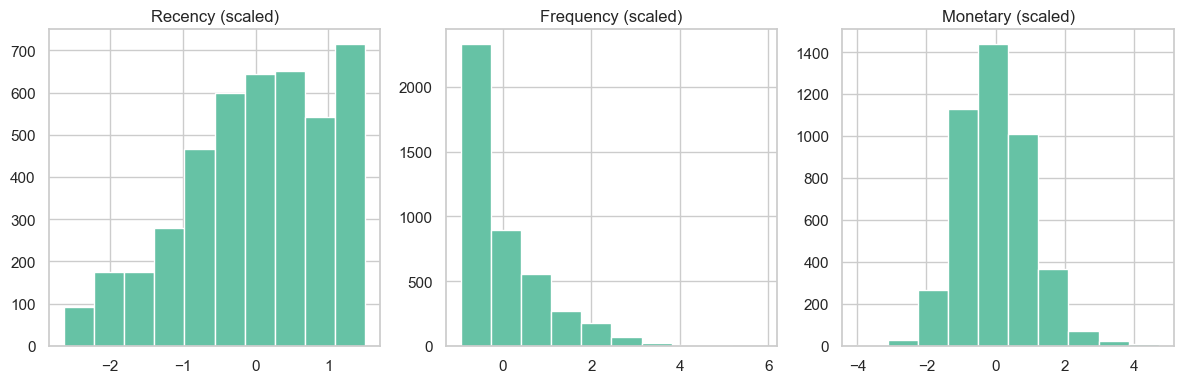

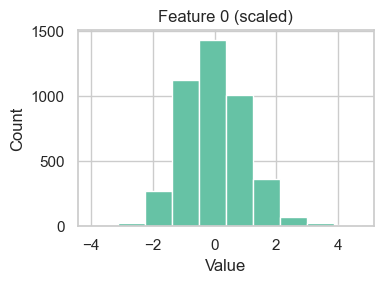

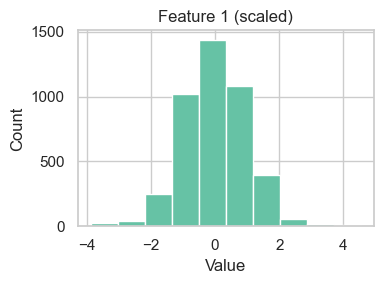

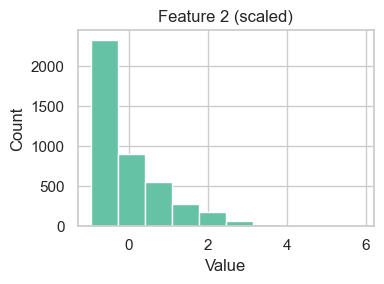

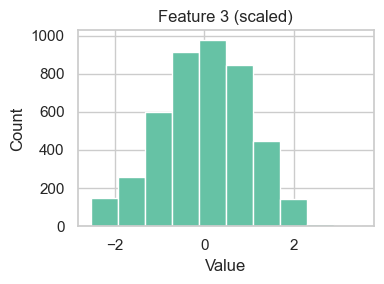

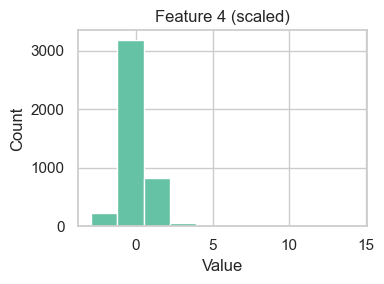

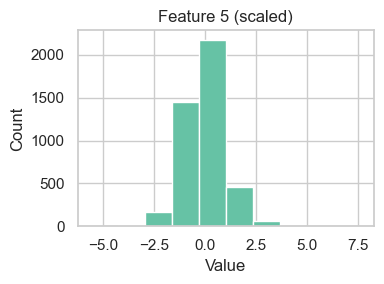

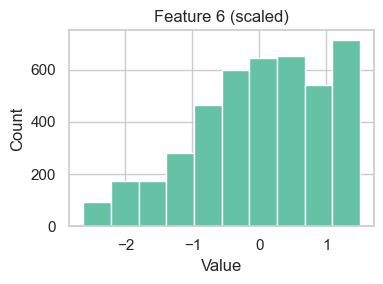

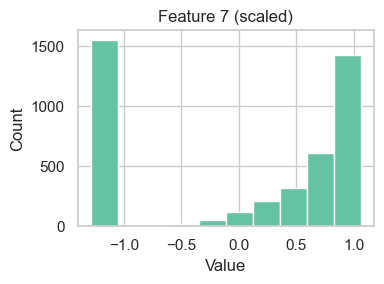

In [19]:

rfm_scaled = X_rfm  

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].hist(rfm_scaled[:, 0])
axes[0].set_title("Recency (scaled)")

axes[1].hist(rfm_scaled[:, 1])
axes[1].set_title("Frequency (scaled)")

axes[2].hist(rfm_scaled[:, 2])
axes[2].set_title("Monetary (scaled)")

plt.tight_layout()
plt.show()



Xf = X_feat  
n_features = Xf.shape[1]

for i in range(n_features):
    plt.figure(figsize=(4,3))
    plt.hist(Xf[:, i])
    plt.title(f"Feature {i} (scaled)")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [20]:
def plot_elbow(X, title="Elbow (SSE) vs K", k_min=2, k_max=10, n_init=10):
    sse = []
    K_range = range(k_min, k_max+1)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=n_init)
        km.fit(X)
        sse.append(km.inertia_)
    plt.figure()
    plt.plot(list(K_range), sse, marker='o')
    plt.title(title)
    plt.xlabel("K")
    plt.ylabel("SSE (Inertia)")
    plt.xticks(list(K_range))
    plt.show()


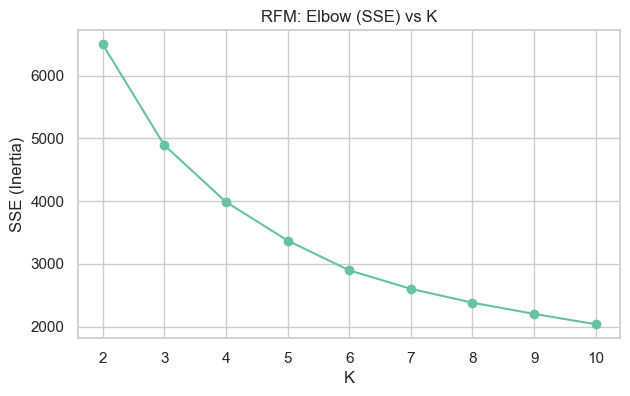

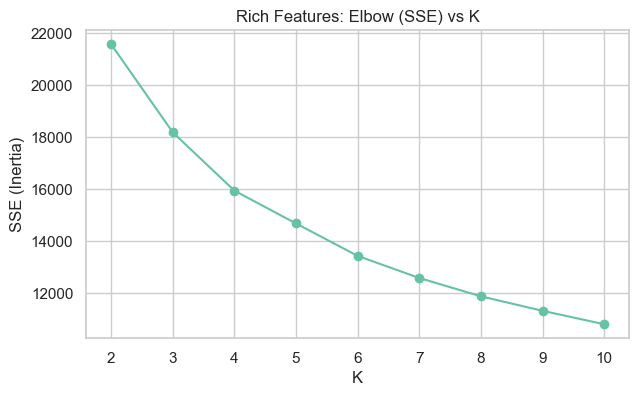

In [21]:
plot_elbow(X_rfm,  title="RFM: Elbow (SSE) vs K")
plot_elbow(X_feat, title="Rich Features: Elbow (SSE) vs K")


In [22]:
K_rfm = 4  
km_rfm = KMeans(n_clusters=K_rfm, random_state=42, n_init=10)
rfm["cluster_rfm"] = km_rfm.fit_predict(X_rfm)

# RFM cluster profile
rfm_profile = rfm.groupby("cluster_rfm")[["Recency","Frequency","Monetary"]].mean().round(2)
counts_rfm = rfm["cluster_rfm"].value_counts().sort_index()
print("RFM: customers per cluster:\n", counts_rfm, "\n")
rfm_profile


RFM: customers per cluster:
 cluster_rfm
0     808
1    1642
2     685
3    1203
Name: count, dtype: int64 



,Recency,Frequency,Monetary
cluster_rfm,,,
0,17.06,2.12,540.35
1,179.43,1.32,347.61
2,10.39,13.99,8290.35
3,67.80,4.21,1829.55


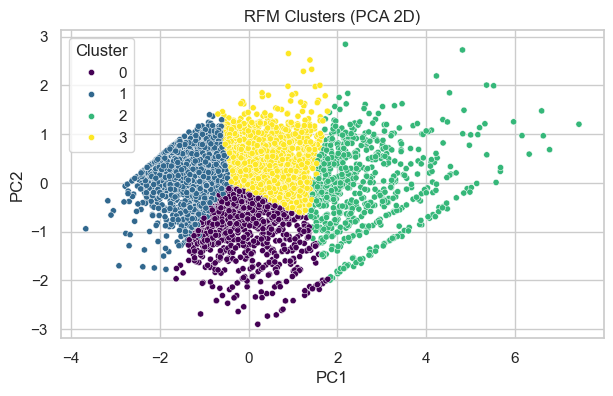

In [23]:
pca_rfm = PCA(n_components=2, random_state=42)
rfm_2d = pca_rfm.fit_transform(X_rfm)

plt.figure()
sns.scatterplot(x=rfm_2d[:,0], y=rfm_2d[:,1], hue=rfm["cluster_rfm"], s=20, palette="viridis")
plt.title("RFM Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


In [24]:
K_feat = 4 
km_feat = KMeans(n_clusters=K_feat, random_state=42, n_init=10)
cust["cluster_feat"] = km_feat.fit_predict(X_feat)

# Rich feature cluster profile
profile_feat = cust.groupby("cluster_feat")[feat_cols].mean().round(2)
counts_feat = cust["cluster_feat"].value_counts().sort_index()
print("Feature-based: customers per cluster:\n", counts_feat, "\n")
profile_feat


Feature-based: customers per cluster:
 cluster_feat
0     775
1    1596
2     949
3    1018
Name: count, dtype: int64 



,total_spend,total_quantity,num_invoices,unique_products,avg_unit_price,avg_basket_value,recency_days,tenure_days
cluster_feat,,,,,,,,
0,168.46,80.58,1.29,10.36,9.10,138.75,167.75,17.10
1,904.18,539.98,3.27,50.79,3.51,296.19,67.94,171.99
2,557.70,326.37,1.08,30.13,3.48,503.51,141.69,0.40
3,6664.35,3848.74,11.10,146.47,3.38,740.34,23.76,272.85


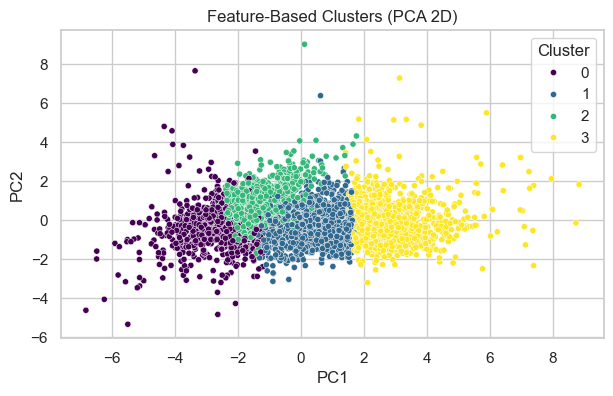

In [25]:
pca_feat = PCA(n_components=2, random_state=42)
feat_2d = pca_feat.fit_transform(X_feat)

plt.figure()
sns.scatterplot(x=feat_2d[:,0], y=feat_2d[:,1], hue=cust["cluster_feat"], s=20, palette="viridis")
plt.title("Feature-Based Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


In [26]:
# Map both cluster assignments to a common table
compare = rfm[["CustomerID","cluster_rfm"]].merge(
    cust[["CustomerID","cluster_feat"]], on="CustomerID", how="inner"
)

# Simple cross-tab to see alignment/differences
pd.crosstab(compare["cluster_rfm"], compare["cluster_feat"])


cluster_feat,0,1,2,3
cluster_rfm,,,,
0,114,473,194,27
1,654,273,715,0
2,0,25,0,660
3,7,825,40,331


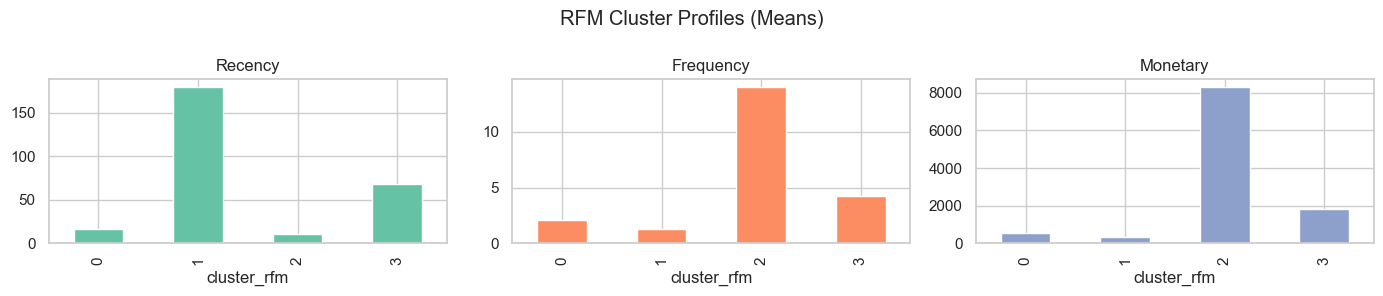

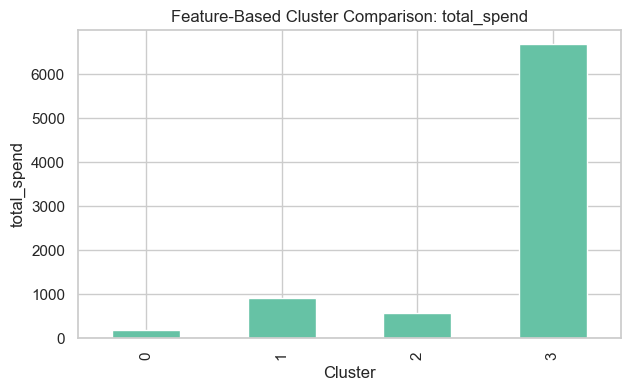

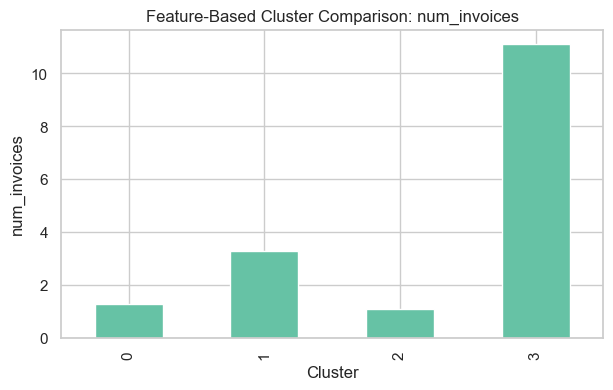

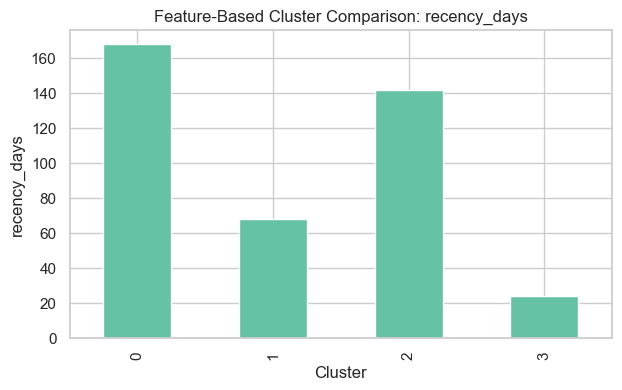

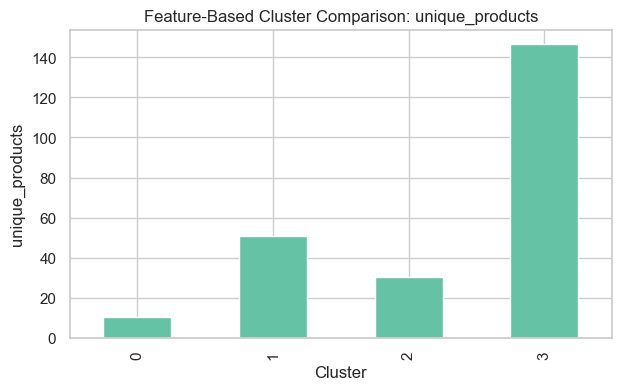

In [27]:
# RFM bars
rfm_profile_plot = rfm_profile.copy()
rfm_profile_plot.plot(kind="bar", subplots=True, layout=(1,3), figsize=(14,3), legend=False, title=["Recency","Frequency","Monetary"])
plt.suptitle("RFM Cluster Profiles (Means)")
plt.tight_layout()
plt.show()

# Rich feature bars (a few key metrics)
for col in ["total_spend", "num_invoices", "recency_days", "unique_products"]:
    plt.figure()
    profile_feat[col].plot(kind="bar")
    plt.title(f"Feature-Based Cluster Comparison: {col}")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.show()
